In [2]:
# загружаем сбалансированный корпус

import pandas as pd

df = pd.read_csv('../data/chatgpt_reviews_clean_balanced.csv')

In [ ]:
!pip install scikit-learn 

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 5.8 MB/s  0:00:03 eta 0:00:01
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [3]:
#импортируем TF IDF и создаем объект, удаляем англ стоп слова, лимит в 5000 слов

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

#читаем корпус, строим словарь, считаем IDF
X = vectorizer.fit_transform(df['content'].astype(str))

In [ ]:
#X.shape
#X[0]
#vectorizer.get_feature_names_out()

array(['00', '083', '10', ..., 'مننہi', 'अड', 'रह'],
      shape=(5000,), dtype=object)

In [11]:
#считаем симиларити между отзывами
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X)

In [17]:
#посмотрим на матрицу

#similarity_matrix.shape
#similarity_matrix[:5, :5]
similarity_matrix[0]

array([1.        , 0.        , 0.        , ..., 0.42349971, 0.        ,
       0.        ], shape=(4620,))

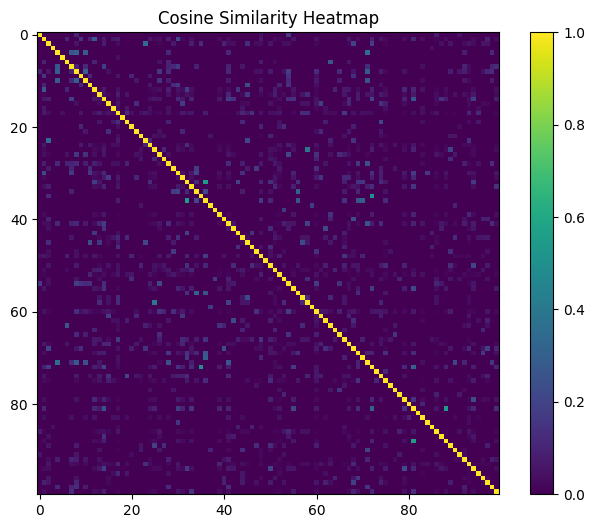

In [16]:
#посмотрим на heatmap
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(
    similarity_matrix[:100, :100],
    cmap='viridis'
)

plt.colorbar()

plt.title('Cosine Similarity Heatmap')

plt.show()

In [22]:
#делаем поиск похожих отзывов

import numpy as np

review_index = 10
similarities = similarity_matrix[review_index]

# самые похожие
similar_indices = np.argsort(similarities)[::-1][1:6]

print("Исходный отзыв:\n")
print(df.iloc[review_index]['content'])

print("\nПохожие отзывы:\n")

for idx in similar_indices:
    print('-' * 50)
    print(df.iloc[idx]['content'])

Исходный отзыв:

I can't remove the popup that says I've reached the free limit for chats with images and it annoys me while I'm reading the conversation.

Похожие отзывы:

--------------------------------------------------
always says I've reached daily limit even though I haven't used it 🫩🙅‍♀️
--------------------------------------------------
I am just starting to use and say the limit is reached for chats
--------------------------------------------------
when I needed it most it says you have reached your limit....duhhhhh
--------------------------------------------------
but have got limit chats
--------------------------------------------------
Nice , you should expand free limit
